# GHSL Heatwave Exposure by Degree of Urbanisation — Brazil 2015 (1 km Tmax)

Identical analysis to notebook 26 but using the **Global Daily Near-Surface Air
Temperature dataset** (1 km) instead of ERA5 (~27 km). No spatial resampling is
required — Tmax, GHS-SMOD and GHS-POP are all natively at 1 km.

| Dataset | Source | Role |
|---|---|---|
| Global Daily Tmax (1 km) | `projects/sat-io/open-datasets/global-daily-air-temp/latin_america` | Heatwave days per pixel |
| GHS-SMOD R2023A | `projects/sat-io/open-datasets/GHS/GHS_SMOD` | Degree of urbanisation (1 km) |
| GHS-POP R2023A | `projects/sat-io/open-datasets/GHS/GHS_POP` | Population count (1 km) |

**Heatwave definition:** ≥ 3 consecutive days where daily Tmax > TX95p threshold  
**Threshold:** 95th percentile of daily Tmax over the 2003–2014 baseline (annual, per pixel)  
**Analysis year:** 2015  
**Country:** Brazil

> **Baseline note:** The dataset covers 2003–2020. Using 2003–2014 (12 years)
> as the baseline keeps the analysis year (2015) out of the reference period.
> This is shorter than the ETCCDI standard 30-year baseline — interpret thresholds
> accordingly.

**Pipeline:**
```
Tmax 2003–2014  →  TX95p threshold image (1 km, Celsius)
Tmax 2015       →  daily exceedance  →  3-day consecutive run  →  heatwave days image (1 km)
GHS-SMOD 2015   →  urbanisation class per pixel (1 km)
GHS-POP  2015   →  population per pixel (1 km)
Combine         →  person-heatwave-days grouped by SMOD class
```

## 0. Configuration

In [14]:
# ── Country & epoch ───────────────────────────────────────────────────────────
COUNTRY_NAME     = "Brazil"
ANALYSIS_YEAR    = 2015
SMOD_POP_YEAR    = 2015

# ── Tmax baseline ─────────────────────────────────────────────────────────────
BASELINE_START   = 2003
BASELINE_END     = 2014

# ── Heatwave definition ───────────────────────────────────────────────────────
PERCENTILE       = 95
MIN_CONSECUTIVE  = 3

# ── Resolution ────────────────────────────────────────────────────────────────
TARGET_SCALE_M   = 1000

# ── GEE ───────────────────────────────────────────────────────────────────────
GEE_PROJECT      = "tl-cities"
TMAX_ID          = "projects/sat-io/open-datasets/global-daily-air-temp/latin_america"
TMAX_BAND        = "b1"         # single band per image; Tmax/Tmin distinguished by property
GHS_SMOD_ID      = "projects/sat-io/open-datasets/GHS/GHS_SMOD"
GHS_POP_ID       = "projects/sat-io/open-datasets/GHS/GHS_POP"
BOUNDARY_ID      = "FAO/GAUL/2015/level0"

# ── Outputs ───────────────────────────────────────────────────────────────────
DRIVE_FOLDER     = "GHSL_Analysis"
OUTPUT_PREFIX    = f"brazil_{ANALYSIS_YEAR}_1km"

import pathlib
OUTPUT_DIR = pathlib.Path("../outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Configuration loaded.")

Configuration loaded.


## 1. Imports & GEE Initialisation

In [15]:
import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from concurrent.futures import ThreadPoolExecutor, as_completed
from IPython.display import display
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.05)

try:
    ee.Initialize(project=GEE_PROJECT)
    print(f"GEE initialized (project: {GEE_PROJECT})")
except Exception:
    ee.Authenticate()
    ee.Initialize(project=GEE_PROJECT)
    print(f"GEE authenticated and initialized (project: {GEE_PROJECT})")

GEE initialized (project: tl-cities)


## 2. Country Boundary

In [16]:
brazil_fc = (
    ee.FeatureCollection(BOUNDARY_ID)
      .filter(ee.Filter.eq("ADM0_NAME", COUNTRY_NAME))
)
brazil = brazil_fc.geometry()

area_km2 = brazil.area(maxError=1000).divide(1e6).getInfo()
bounds   = brazil.bounds().getInfo()["coordinates"][0]
lon_min  = min(c[0] for c in bounds)
lon_max  = max(c[0] for c in bounds)
lat_min  = min(c[1] for c in bounds)
lat_max  = max(c[1] for c in bounds)

print(f"{COUNTRY_NAME} boundary loaded")
print(f"  Area : {area_km2:,.0f} km²")
print(f"  Lon  : {lon_min:.2f} → {lon_max:.2f}")
print(f"  Lat  : {lat_min:.2f} → {lat_max:.2f}")

Brazil boundary loaded
  Area : 8,518,291 km²
  Lon  : -73.99 → -28.85
  Lat  : -33.75 → 5.26


## 3. Tmax TX95p Threshold (2003–2014 Baseline)

Per-pixel 95th percentile of daily Tmax computed server-side. Data are already
in Celsius at 1 km — no unit conversion or resampling needed. Evaluated lazily.

In [17]:
tmax_col_full = (
    ee.ImageCollection(TMAX_ID)
      .filter(ee.Filter.eq("prop_type", "tmax"))   # exclude Tmin images
)

baseline_col = (
    tmax_col_full
      .filterDate(f"{BASELINE_START}-01-01", f"{BASELINE_END + 1}-01-01")
      .filterBounds(brazil)
      .select(TMAX_BAND)
)
n_baseline = baseline_col.size().getInfo()
print(f"Baseline collection: {BASELINE_START}–{BASELINE_END}")
print(f"  Images : {n_baseline:,} daily Tmax images")

# Per-pixel TX95p threshold — lazy server-side computation.
# Values are int16 (possibly scaled); threshold and daily images share the
# same scale so the exceedance comparison is correct without conversion.
threshold = (
    baseline_col
      .reduce(ee.Reducer.percentile([PERCENTILE]))
      .rename("tx95p")
      .clip(brazil)
)
print(f"TX{PERCENTILE}p threshold image defined (lazy).")

Baseline collection: 2003–2014
  Images : 4,380 daily Tmax images
TX95p threshold image defined (lazy).


## 4. Heatwave Days in 2015

Same 3-day consecutive run logic as notebook 26:

1. `exc[d] = 1` if Tmax[d] > TX95p, else 0.
2. Forward 3-day sum `S[d] = exc[d] + exc[d+1] + exc[d+2]`.
3. Day `d` is a heatwave day if `exc[d] = 1` AND `S[d] ≥ 3` OR `S[d−1] ≥ 3` OR `S[d−2] ≥ 3`.
4. Sum across the year → heatwave days per pixel.

In [22]:
tmax_2015 = (
    tmax_col_full
      .filterDate(f"{ANALYSIS_YEAR}-01-01", f"{ANALYSIS_YEAR + 1}-01-01")
      .filterBounds(brazil)
      .select(TMAX_BAND)
      .sort("system:time_start")
)
n_days = tmax_2015.size().getInfo()
print(f"Tmax {ANALYSIS_YEAR}: {n_days} daily images")

def mark_exceedance(img):
    return (img.gt(threshold)
              .rename("exc")
              .copyProperties(img, ["system:time_start"]))

exc_col  = tmax_2015.map(mark_exceedance)
exc_list = exc_col.toList(n_days)

exc_imgs = [ee.Image(exc_list.get(d)).rename("e") for d in range(n_days)]
zero_img = ee.Image.constant(0).rename("e")

def safe_exc(d):
    return exc_imgs[d] if 0 <= d < n_days else zero_img

print("Building heatwave computation graph...", end=" ")
hw_images = []
for d in range(n_days):
    e0    = safe_exc(d)
    s_d   = safe_exc(d  ).add(safe_exc(d+1)).add(safe_exc(d+2))
    s_dm1 = safe_exc(d-1).add(safe_exc(d  )).add(safe_exc(d+1))
    s_dm2 = safe_exc(d-2).add(safe_exc(d-1)).add(safe_exc(d  ))
    in_run = (
        s_d  .gte(MIN_CONSECUTIVE)
        .Or(s_dm1.gte(MIN_CONSECUTIVE))
        .Or(s_dm2.gte(MIN_CONSECUTIVE))
    )
    hw_images.append(e0.And(in_run).rename("hw_day"))

hw_days_computed = (
    ee.ImageCollection(hw_images)
      .sum()
      .rename("hw_days")
      .clip(brazil)
)
print("done.")

# ── Export to GEE asset to flatten the computation graph ─────────────────────
# The 365-image graph is too large to pass directly to reduceRegion.
# Export collapses it to a simple asset reference, avoiding memory errors.
ASSET_ID = f"projects/{GEE_PROJECT}/assets/{OUTPUT_PREFIX}_hw_days"

task = ee.batch.Export.image.toAsset(
    image       = hw_days_computed,
    description = f"{OUTPUT_PREFIX}_hw_days_export",
    assetId     = ASSET_ID,
    region      = brazil,
    scale       = TARGET_SCALE_M,
    crs         = "EPSG:4326",
    maxPixels   = 1e12,
)
task.start()
print(f"\nExport task started → asset: {ASSET_ID}")
print("Monitor at https://code.earthengine.google.com/tasks")
print("Run the next cell once the task shows 'Completed'.")

Tmax 2015: 365 daily images
Building heatwave computation graph... done.

Export task started → asset: projects/tl-cities/assets/brazil_2015_1km_hw_days
Monitor at https://code.earthengine.google.com/tasks
Run the next cell once the task shows 'Completed'.


In [23]:
# ── Load hw_days from asset (run after export task completes) ─────────────────
# Loading from an asset gives GEE a simple image reference with no complex
# computation graph, avoiding the memory limit error in reduceRegion.
hw_days = ee.Image(ASSET_ID).rename("hw_days").clip(brazil)

# Quick check — sample pixel count (non-zero heatwave days)
n_hw_pixels = hw_days.gt(0).reduceRegion(
    reducer   = ee.Reducer.sum(),
    geometry  = brazil,
    scale     = 5000,        # coarse scale just for the sanity check
    maxPixels = 1e9,
    bestEffort= True,
).getInfo()
print(f"Asset loaded: {ASSET_ID}")
print(f"Pixels with ≥1 heatwave day (sampled at 5 km): {n_hw_pixels.get('hw_days', 0):,.0f}")

Asset loaded: projects/tl-cities/assets/brazil_2015_1km_hw_days
Pixels with ≥1 heatwave day (sampled at 5 km): 331,657


## 5. GHS-SMOD, GHS-POP and Person-Heatwave-Days

All three layers (Tmax-derived heatwave days, SMOD, POP) are at 1 km — no
reprojection of the heatwave image is needed.

In [24]:
import datetime

smod_col = ee.ImageCollection(GHS_SMOD_ID)
pop_col  = ee.ImageCollection(GHS_POP_ID)

# Select 2015 epoch by matching year string in system:index
# e.g. "GHS_SMOD_E2015_GLOBE_R2023A_54009_1000_V1_0"
smod_raw = smod_col.filter(
    ee.Filter.stringContains("system:index", str(SMOD_POP_YEAR))
).first()
pop_raw  = pop_col.filter(
    ee.Filter.stringContains("system:index", str(SMOD_POP_YEAR))
).first()

smod_band = smod_raw.bandNames().getInfo()[0]
pop_band  = pop_raw.bandNames().getInfo()[0]
print(f"SMOD {SMOD_POP_YEAR}: {smod_raw.get('system:index').getInfo()}  band={smod_band}")
print(f"POP  {SMOD_POP_YEAR}: {pop_raw.get('system:index').getInfo()}  band={pop_band}")

smod_img = (
    smod_raw.select([smod_band]).rename("smod")
            .reproject(crs="EPSG:4326", scale=TARGET_SCALE_M)
            .clip(brazil)
)
pop_img = (
    pop_raw.select([pop_band]).rename("population")
           .reproject(crs="EPSG:4326", scale=TARGET_SCALE_M)
           .clip(brazil)
)

# hw_days is already at 1 km EPSG:4326 — multiply directly
hw_days_1km = hw_days.reproject(crs="EPSG:4326", scale=TARGET_SCALE_M)
person_hw_days = hw_days_1km.multiply(pop_img).rename("person_hw_days")

print("\nsmod_img, pop_img, hw_days_1km, person_hw_days defined.")

SMOD 2015: GHS_SMOD_E2015_GLOBE_R2023A_54009_1000_V1_0  band=b1
POP  2015: GHS_POP_E2015_GLOBE_R2023A_54009_100_V1_0  band=b1

smod_img, pop_img, hw_days_1km, person_hw_days defined.


## 6. Person-Heatwave-Days by SMOD Class

7 parallel reductions — one `getInfo` per SMOD class.  
**Expect 5–15 minutes** depending on GEE server load.

In [25]:
SMOD_CLASSES = {
    30: "Urban Centre",
    23: "Dense Urban Cluster",
    22: "Semi-dense Urban Cluster",
    21: "Suburban / Peri-urban",
    13: "Rural Cluster",
    12: "Low Density Rural",
    11: "Very Low Density Rural",
}
SMOD_ORDER = [30, 23, 22, 21, 13, 12, 11]

In [26]:
def stats_for_smod(smod_code, _smod_img, _pop_img, _person_hw_days, _brazil):
    """Sum population and person-heatwave-days for one SMOD class."""
    mask   = _smod_img.eq(smod_code)
    result = (
        _pop_img.rename("population")
                .addBands(_person_hw_days.rename("person_hw_days"))
                .updateMask(mask)
                .reduceRegion(
                    reducer   = ee.Reducer.sum(),
                    geometry  = _brazil,
                    scale     = TARGET_SCALE_M,
                    maxPixels = 1e12,
                    bestEffort= True,
                )
                .getInfo()
    )
    return {
        "smod_code":      smod_code,
        "smod_label":     SMOD_CLASSES[smod_code],
        "population":     result.get("population")     or 0.0,
        "person_hw_days": result.get("person_hw_days") or 0.0,
    }


print(f"Running {len(SMOD_ORDER)} reductions (3 at a time to stay within GEE memory limits)...")

rows = []
with ThreadPoolExecutor(max_workers=3) as pool:
    futures = {
        pool.submit(stats_for_smod, sc, smod_img, pop_img, person_hw_days, brazil): sc
        for sc in SMOD_ORDER
    }
    for future in as_completed(futures):
        row = future.result()
        rows.append(row)
        print(
            f"  {row['smod_label']:28s}  "
            f"pop={row['population']/1e6:6.2f}M  "
            f"person-hw-days={row['person_hw_days']:,.0f}",
            end="\r"
        )

print("\nDone.")

df = (
    pd.DataFrame(rows)
      .sort_values("smod_code", ascending=False)
      .reset_index(drop=True)
)
df["mean_hw_days"] = df["person_hw_days"] / df["population"].replace(0, float("nan"))

csv_path = OUTPUT_DIR / f"{OUTPUT_PREFIX}_person_hw_days_by_smod.csv"
df.to_csv(csv_path, index=False)
print(f"Results saved → {csv_path}")

Running 7 reductions (3 at a time to stay within GEE memory limits)...
  Very Low Density Rural        pop=  0.22M  person-hw-days=3,643,2765
Done.
Results saved → ../outputs/brazil_2015_1km_person_hw_days_by_smod.csv


## 7. Results & Visualisations

In [27]:
smod_label_order = [SMOD_CLASSES[c] for c in SMOD_ORDER]
df_plot = df.set_index("smod_label").reindex(smod_label_order)

summary = pd.DataFrame({
    "Population":            df_plot["population"].map(lambda x: f"{x/1e6:.2f}M"),
    "Person-heatwave-days":  df_plot["person_hw_days"].map(lambda x: f"{x:,.0f}"),
    "Mean hw days / person": df_plot["mean_hw_days"].map(lambda x: f"{x:.1f}"),
})
summary.index.name = "SMOD class (urban → rural)"

print(f"{COUNTRY_NAME} {ANALYSIS_YEAR} — Person-Heatwave-Days by Degree of Urbanisation")
print(f"(heatwave = ≥{MIN_CONSECUTIVE} consecutive days above TX{PERCENTILE}p, baseline {BASELINE_START}–{BASELINE_END})\n")
display(summary)

national_phd = df["person_hw_days"].sum()
national_pop = df["population"].sum()
print(f"\nNational total  person-heatwave-days : {national_phd:,.0f}")
print(f"National mean   hw days per person    : {national_phd / national_pop:.1f}")

Brazil 2015 — Person-Heatwave-Days by Degree of Urbanisation
(heatwave = ≥3 consecutive days above TX95p, baseline 2003–2014)



,Population,Person-heatwave-days,Mean hw days / person
SMOD class (urban → rural),,,
Urban Centre,1.16M,"21,654,385",18.7
Dense Urban Cluster,0.30M,"5,340,072",17.7
Semi-dense Urban Cluster,0.05M,"773,661",16.8
Suburban / Peri-urban,0.16M,"2,644,096",16.9
Rural Cluster,0.10M,"1,601,495",16.4
Low Density Rural,0.18M,"2,855,059",15.8
Very Low Density Rural,0.22M,"3,643,276",16.6



National total  person-heatwave-days : 38,512,044
National mean   hw days per person    : 17.9


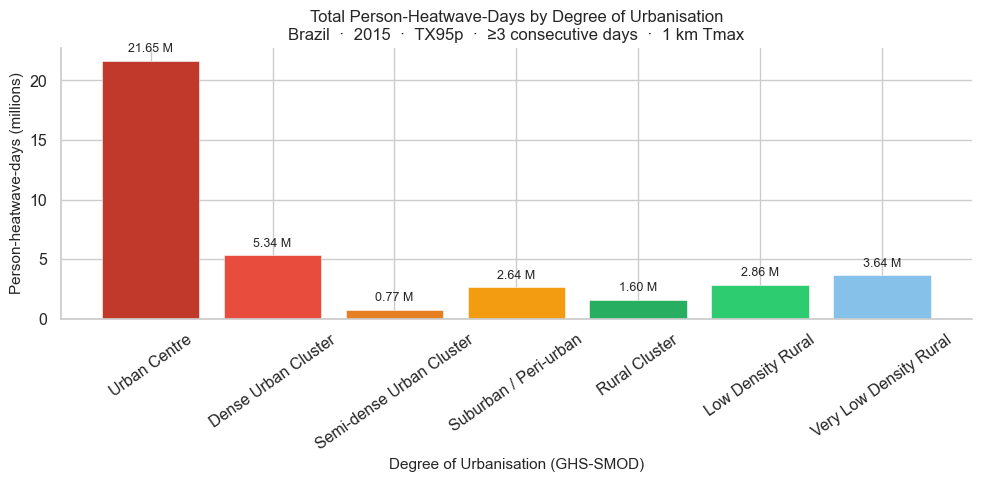

In [28]:
# ── Figure 1: Total person-heatwave-days by SMOD class ───────────────────────
colors = ["#c0392b", "#e74c3c", "#e67e22", "#f39c12", "#27ae60", "#2ecc71", "#85c1e9"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    smod_label_order,
    df_plot["person_hw_days"].values / 1e6,
    color=colors, edgecolor="white", linewidth=0.4
)
ax.bar_label(bars, fmt="%.2f M", padding=4, fontsize=9)
ax.set_xlabel("Degree of Urbanisation (GHS-SMOD)", fontsize=11)
ax.set_ylabel("Person-heatwave-days (millions)", fontsize=11)
ax.set_title(
    f"Total Person-Heatwave-Days by Degree of Urbanisation\n"
    f"{COUNTRY_NAME}  ·  {ANALYSIS_YEAR}  ·  TX{PERCENTILE}p  ·  "
    f"≥{MIN_CONSECUTIVE} consecutive days  ·  1 km Tmax",
    fontsize=12
)
ax.tick_params(axis="x", rotation=35)
sns.despine()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{OUTPUT_PREFIX}_person_hw_days_bar.png", dpi=150, bbox_inches="tight")
plt.show()

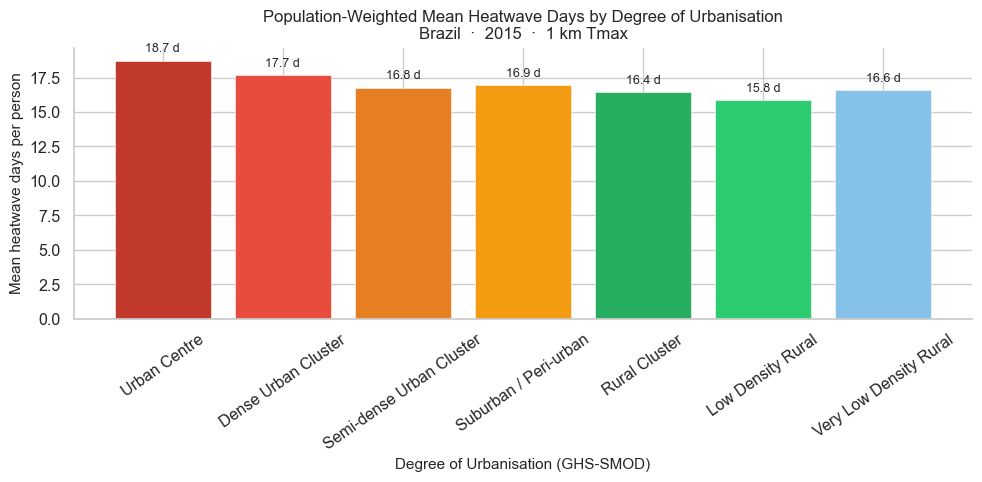

In [29]:
# ── Figure 2: Population-weighted mean heatwave days per person ───────────────
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    smod_label_order,
    df_plot["mean_hw_days"].values,
    color=colors, edgecolor="white", linewidth=0.4
)
ax.bar_label(bars, fmt="%.1f d", padding=4, fontsize=9)
ax.set_xlabel("Degree of Urbanisation (GHS-SMOD)", fontsize=11)
ax.set_ylabel("Mean heatwave days per person", fontsize=11)
ax.set_title(
    f"Population-Weighted Mean Heatwave Days by Degree of Urbanisation\n"
    f"{COUNTRY_NAME}  ·  {ANALYSIS_YEAR}  ·  1 km Tmax",
    fontsize=12
)
ax.tick_params(axis="x", rotation=35)
sns.despine()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{OUTPUT_PREFIX}_mean_hw_days_bar.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Export Stacked Raster to Google Drive (Optional)

| Band | Content |
|---|---|
| `hw_days` | Heatwave days in 2015 |
| `person_hw_days` | hw_days × population per pixel |
| `smod` | GHS-SMOD class code |
| `population` | GHS-POP count per pixel |

In [30]:
stacked = (
    hw_days_1km.rename("hw_days")
               .addBands(person_hw_days.rename("person_hw_days"))
               .addBands(smod_img.rename("smod"))
               .addBands(pop_img.rename("population"))
)

task = ee.batch.Export.image.toDrive(
    image          = stacked,
    description    = f"{OUTPUT_PREFIX}_ghsl_heatwave_smod_pop_1km",
    folder         = DRIVE_FOLDER,
    fileNamePrefix = f"{OUTPUT_PREFIX}_ghsl_heatwave_smod_pop_1km",
    region         = brazil,
    scale          = TARGET_SCALE_M,
    crs            = "EPSG:4326",
    maxPixels      = 1e12,
    fileFormat     = "GeoTIFF",
)
task.start()
print(f"Export task submitted: {OUTPUT_PREFIX}_ghsl_heatwave_smod_pop_1km")
print(f"Folder  : Google Drive / {DRIVE_FOLDER}")
print(f"Monitor : https://code.earthengine.google.com/tasks")

Export task submitted: brazil_2015_1km_ghsl_heatwave_smod_pop_1km
Folder  : Google Drive / GHSL_Analysis
Monitor : https://code.earthengine.google.com/tasks


## 9. Interactive Map (Optional)

Run after Section 6 has completed — GEE will have cached intermediate results
so tile rendering is faster.

In [31]:
Map = geemap.Map()
Map.centerObject(brazil, zoom=4)

Map.addLayer(
    hw_days_1km.updateMask(hw_days_1km.gt(0)),
    {"min": 1, "max": 60,
     "palette": ["#ffffb2", "#fecc5c", "#fd8d3c", "#f03b20", "#bd0026"]},
    f"Heatwave days {ANALYSIS_YEAR} (1 km Tmax)"
)
Map.addLayer(
    threshold,
    {"min": 25, "max": 42,
     "palette": ["#2166ac", "#f7f7f7", "#d73027"]},
    f"TX{PERCENTILE}p threshold (°C)",
    shown=False
)
Map.addLayer(
    smod_img,
    {"min": 10, "max": 30,
     "palette": ["#d4e6f1", "#85c1e9", "#2e86c1",
                 "#1a5276", "#f0e68c", "#f4d03f", "#e67e22", "#c0392b"]},
    "GHS-SMOD 2015",
    shown=False
)
Map.addLayer(
    ee.Image().paint(brazil_fc, 1, 2),
    {"palette": ["000000"]},
    f"{COUNTRY_NAME} boundary"
)
Map

Map(center=[-10.613275552794567, -53.19823757236853], controls=(WidgetControl(options=['position', 'transparen…

## Notes & Limitations

1. **Short baseline**: 2003–2014 is only 12 years vs the ETCCDI standard 30. The
   TX95p threshold may be less stable, particularly in regions with high inter-annual
   variability. Results should be interpreted as indicative.

2. **Regional collection**: The `latin_america` collection covers the full continent.
   `filterBounds(brazil)` restricts tile downloads to Brazil but the collection is
   global — no data gap risk.

3. **Units**: Tmax is in degrees Celsius — no conversion applied.

4. **`bestEffort=True`**: GEE may increase computation scale to avoid timeout.

5. **Comparison with notebook 26 (ERA5)**: The 1 km Tmax dataset captures finer
   spatial structure (urban heat island, topography) that ERA5 at ~27 km smooths
   out. Differences in results reflect both the resolution and the different
   baseline periods (1981–2010 vs 2003–2014).